In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
pd.set_option('display.float_format', lambda x: '%.3f' % x)
plt.rcParams["figure.figsize"] = (10, 6)

In [4]:
import urllib.request
import os

# Download KDDTrain+ and KDDTest+
base_url = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/"

files = ["KDDTrain+.txt", "KDDTest+.txt"]

for f in files:
    if not os.path.exists(f):
        print(f"Downloading {f}...")
        urllib.request.urlretrieve(base_url + f, f)
        print(f"  ✓ Saved as {f}")
    else:
        print(f"  {f} already exists, skipping.")

  ✓ Saved as KDDTrain+.txt
  ✓ Saved as KDDTest+.txt


In [5]:
# ── Load NSL-KDD ──────────────────────────────────────────────────────────────
df_0 = pd.read_csv("KDDTrain+.txt", header=None)
df = df_0.copy()

columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes',
    'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
    'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
    'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
    'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
    'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
    'dst_host_srv_count', 'dst_host_same_srv_rate',
    'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
    'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate', 'attack', 'level'
]
df.columns = columns
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (125973, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.170,0.030,0.170,0.000,0.000,0.000,0.050,0.000,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.000,0.600,0.880,0.000,0.000,0.000,0.000,0.000,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.100,0.050,0.000,0.000,1.000,1.000,0.000,0.000,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.000,0.000,0.030,0.040,0.030,0.010,0.000,0.010,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,normal,21


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  object 
 2   service                      125973 non-null  object 
 3   flag                         125973 non-null  object 
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13 

In [7]:
df.isnull().sum().sum()   # Should be 0

np.int64(0)

In [8]:
df['label'] = df['attack'].apply(lambda x: 0 if x == 'normal' else 1)
print(df['label'].value_counts())

label
0    67343
1    58630
Name: count, dtype: int64


In [9]:
import urllib.request
import os

log_url  = "https://raw.githubusercontent.com/logpai/loghub/master/HDFS/HDFS_2k.log"
log_file = "HDFS_2k.log"

if not os.path.exists(log_file):
    print("Downloading HDFS log file...")
    urllib.request.urlretrieve(log_url, log_file)
    print("✓ Saved as HDFS_2k.log")
else:
    print("✓ HDFS_2k.log already exists")

✓ Saved as HDFS_2k.log


In [10]:
with open("HDFS_2k.log", "r") as f:
    all_logs = f.readlines()

n = len(df)
raw_logs = [all_logs[i % len(all_logs)].strip() for i in range(n)]

print(f"✓ Loaded {len(all_logs)} real log lines")
print(f"✓ Mapped to {n} NSL-KDD rows")
for l in raw_logs[:3]:
    print(" ", l)

✓ Loaded 2000 real log lines
✓ Mapped to 125973 NSL-KDD rows
  081109 203615 148 INFO dfs.DataNode$PacketResponder: PacketResponder 1 for block blk_38865049064139660 terminating
  081109 203807 222 INFO dfs.DataNode$PacketResponder: PacketResponder 0 for block blk_-6952295868487656571 terminating
  081109 204005 35 INFO dfs.FSNamesystem: BLOCK* NameSystem.addStoredBlock: blockMap updated: 10.251.73.220:50010 is added to blk_7128370237687728475 size 67108864


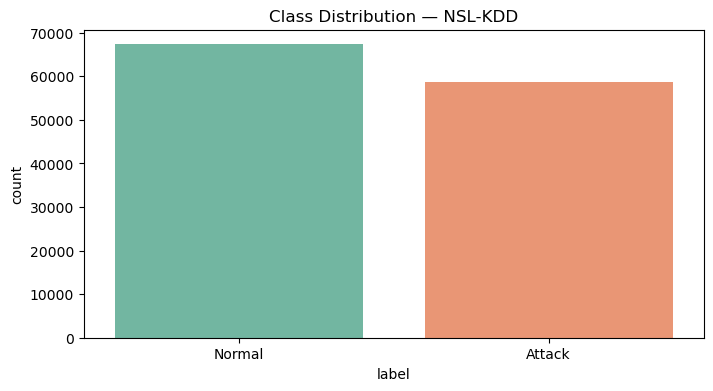

In [11]:
plt.figure(figsize=(8, 4))
sns.countplot(x='label', data=df, palette='Set2')
plt.xticks([0, 1], ['Normal', 'Attack'])
plt.title('Class Distribution — NSL-KDD')
plt.show()

In [12]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

le = LabelEncoder()
for col in ['protocol_type', 'service', 'flag']:
    df[col] = le.fit_transform(df[col])

# Drop original attack string and level column — keep binary label
net_features = df.drop(columns=['attack', 'level', 'label'])
net_labels   = df['label'].values

print(f"Network feature matrix: {net_features.shape}  (41 structured columns)")

Network feature matrix: (125973, 41)  (41 structured columns)


In [13]:
import re
from sklearn.feature_extraction.text import TfidfVectorizer

# ── Simulate raw log messages ─────────────────────────────────────────────────
np.random.seed(42)
n = len(df)

normal_templates = [
    "INFO  Connection established from {ip} port {port} service {svc}",
    "INFO  User logged in successfully from {ip}",
    "DEBUG Packet received src={ip} dst_bytes={b} protocol=tcp",
    "INFO  Service {svc} request completed normally",
    "DEBUG Auth success for user guest from {ip}",
]
attack_templates = [
    "ERROR Failed login attempt {n} times from {ip}",
    "WARN  Port scan detected from {ip} on port {port}",
    "CRIT  Root shell spawned from {ip} unexpected",
    "ERROR Buffer overflow attempt detected src={ip}",
    "WARN  DoS flood detected service={svc} count={n}",
]

def gen_log(is_attack):
    templates = attack_templates if is_attack else normal_templates
    t = np.random.choice(templates)
    return t.format(
        ip=f"192.168.{np.random.randint(0,255)}.{np.random.randint(1,255)}",
        port=np.random.randint(1, 65535),
        svc=np.random.choice(['http', 'ftp', 'ssh', 'smtp', 'dns']),
        b=np.random.randint(0, 10000),
        n=np.random.randint(1, 20)
    )

raw_logs = [gen_log(lbl) for lbl in net_labels]
print("Sample log entries:")
for l in raw_logs[:3]: print(" ", l)

Sample log entries:
  INFO  Service dns request completed normally
  DEBUG Packet received src=192.168.202.88 dst_bytes=8322 protocol=tcp
  ERROR Buffer overflow attempt detected src=192.168.157.38


In [14]:
class DrainParser:
    """Lightweight Drain-inspired log parser."""
    def __init__(self):
        self.templates = {}
        self._ip   = re.compile(r'\b(?:\d{1,3}\.){3}\d{1,3}\b')
        self._port = re.compile(r'\bport\s*=?\s*\d+\b', re.I)
        self._num  = re.compile(r'\b\d+\b')

    def _normalize(self, line):
        line = self._ip.sub('<IP>', line)
        line = self._port.sub('port=<PORT>', line)
        line = self._num.sub('<NUM>', line)
        return line.strip()

    def parse_batch(self, lines):
        return [self._normalize(l) for l in lines]

parser = DrainParser()
parsed_logs = parser.parse_batch(raw_logs)

print("Parsed log templates (first 3):")
for p in parsed_logs[:3]: print(" ", p)

Parsed log templates (first 3):
  INFO  Service dns request completed normally
  DEBUG Packet received src=<IP> dst_bytes=<NUM> protocol=tcp
  ERROR Buffer overflow attempt detected src=<IP>


In [15]:
tfidf = TfidfVectorizer(max_features=50, ngram_range=(1, 2))
log_features_sparse = tfidf.fit_transform(parsed_logs)
log_features = log_features_sparse.toarray()

print(f"Log feature matrix (TF-IDF): {log_features.shape}  (50 TF-IDF dimensions)")

Log feature matrix (TF-IDF): (125973, 50)  (50 TF-IDF dimensions)


In [16]:
from sklearn.preprocessing import StandardScaler

# Scale network features before fusion
scaler_net = StandardScaler()
net_scaled = scaler_net.fit_transform(net_features)

# Scale log features before fusion
scaler_log = StandardScaler()
log_scaled = scaler_log.fit_transform(log_features)

# ── Concatenation Fusion ──────────────────────────────────────────────────────
X_fused = np.concatenate([net_scaled, log_scaled], axis=1)
y       = net_labels

print(f"Network features : {net_scaled.shape[1]}")
print(f"Log TF-IDF features: {log_scaled.shape[1]}")
print(f"Fused feature matrix: {X_fused.shape}  (heterogeneous fusion)")

Network features : 41
Log TF-IDF features: 50
Fused feature matrix: (125973, 91)  (heterogeneous fusion)


In [17]:
from sklearn.model_selection import train_test_split

X_train_f, X_test_f, y_train, y_test = train_test_split(
    X_fused, y, test_size=0.10, random_state=43, stratify=y
)
print(f"Train: {X_train_f.shape}  |  Test: {X_test_f.shape}")

Train: (113375, 91)  |  Test: (12598, 91)


In [18]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

input_dim = X_train_f.shape[1]
ENCODING_DIM = 10          # ← bottleneck: 10 compressed features

# ── Build Autoencoder ─────────────────────────────────────────────────────────
inputs  = keras.Input(shape=(input_dim,))
encoded = layers.Dense(64, activation='relu')(inputs)
encoded = layers.Dense(32, activation='relu')(encoded)
bottleneck = layers.Dense(ENCODING_DIM, activation='relu', name='bottleneck')(encoded)
decoded = layers.Dense(32, activation='relu')(bottleneck)
decoded = layers.Dense(64, activation='relu')(decoded)
outputs = layers.Dense(input_dim, activation='linear')(decoded)

autoencoder = keras.Model(inputs, outputs, name='Autoencoder')
encoder     = keras.Model(inputs, bottleneck, name='Encoder')

autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

Model: "Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 91)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         5,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 10)             │           330 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 91)             │         5,915 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,677 (65.14 KB)

 Trainable params: 16,677 (65.14 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# ── Train Autoencoder (unsupervised — reconstruct input) ──────────────────────
history = autoencoder.fit(
    X_train_f, X_train_f,
    epochs=30,
    batch_size=256,
    validation_split=0.1,
    verbose=1
)

Epoch 1/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.3918 - val_loss: 0.1467
Epoch 2/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.2131 - val_loss: 0.0953
Epoch 3/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1782 - val_loss: 0.0802
Epoch 4/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1570 - val_loss: 0.0731
Epoch 5/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1389 - val_loss: 0.0677
Epoch 6/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1282 - val_loss: 0.1106
Epoch 7/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1193 - val_loss: 0.1034
Epoch 8/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1176 - val_loss: 0.0674
Epoch 9/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1096 - val_loss: 0.0654
Epoch 10/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1031 - val_loss: 0.0617
Epoch 11/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0854 - val_loss: 0.0641
Epoch 12/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

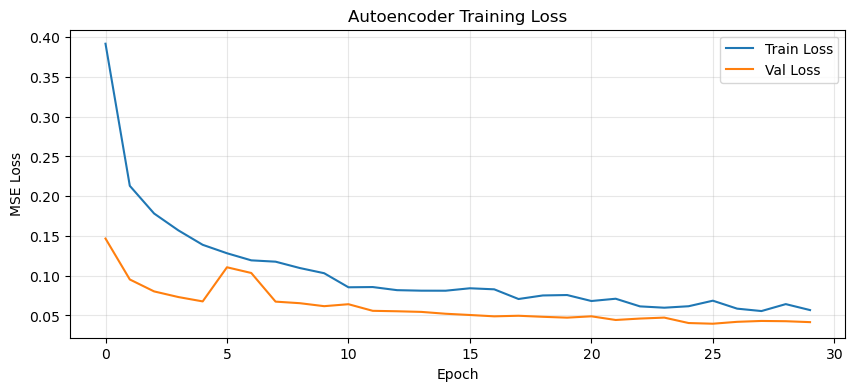

In [20]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Autoencoder Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [21]:
# ── Extract 10 Compressed Features from Encoder ───────────────────────────────
X_train_enc = encoder.predict(X_train_f, verbose=0)
X_test_enc  = encoder.predict(X_test_f,  verbose=0)

print(f"Compressed feature matrix (train): {X_train_enc.shape}  ← 10 features")
print(f"Compressed feature matrix (test) : {X_test_enc.shape}")

Compressed feature matrix (train): (113375, 10)  ← 10 features
Compressed feature matrix (test) : (12598, 10)


In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier,
                              StackingClassifier, VotingClassifier)
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve, auc,
                             accuracy_score, f1_score, precision_score,
                             recall_score, roc_auc_score)

# ── Shared Base Models (Level-0): XGB + RF + LR ───────────────────────────────
base_models = [
    ('xgb', XGBClassifier(
        colsample_bytree=0.5, learning_rate=0.1,
        max_depth=6, n_estimators=128,
        subsample=0.8, random_state=42,
        eval_metric='logloss', use_label_encoder=False
    )),
    ('rf', RandomForestClassifier(
        n_estimators=100, max_depth=10,
        random_state=42, n_jobs=-1
    )),
    ('lr', LogisticRegression(random_state=42, max_iter=500))
]

# ── Model 1: Stacking (meta-learner = LR) ─────────────────────────────────────
meta_lr = LogisticRegression(random_state=42, max_iter=500)

stacking_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_lr,
    cv=5,
    n_jobs=-1,
    passthrough=False    # only meta-features (3 base preds) fed to meta-LR
)

# ── Model 2: Voting (soft vote over XGB + RF + LR) ────────────────────────────
voting_model = VotingClassifier(
    estimators=base_models,
    voting='soft',
    n_jobs=-1
)

# ── Train Both ────────────────────────────────────────────────────────────────
stacking_model.fit(X_train_enc, y_train)
print("Stacking Ensemble (meta-LR) trained successfully.")

voting_model.fit(X_train_enc, y_train)
print("Voting Ensemble (soft) trained successfully.")

Stacking Ensemble (meta-LR) trained successfully.
Voting Ensemble (soft) trained successfully.


In [23]:
# ── Predictions & Probabilities ───────────────────────────────────────────────
y_pred_stk = stacking_model.predict(X_test_enc)
y_prob_stk = stacking_model.predict_proba(X_test_enc)[:, 1]

y_pred_vot = voting_model.predict(X_test_enc)
y_prob_vot = voting_model.predict_proba(X_test_enc)[:, 1]

# ── Unified models dict (used by all plot cells below) ────────────────────────
models = {
    'Stacking (meta-LR)': (y_pred_stk, y_prob_stk),
    'Voting (Soft)':      (y_pred_vot, y_prob_vot),
}

# ── Classification Reports ────────────────────────────────────────────────────
for name, (y_pred, _) in models.items():
    print(f"\n{'='*55}")
    print(f"  {name}")
    print('='*55)
    print(classification_report(y_test, y_pred,
                                target_names=['Normal', 'Attack']))


  Stacking (meta-LR)
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      6735
      Attack       1.00      1.00      1.00      5863

    accuracy                           1.00     12598
   macro avg       1.00      1.00      1.00     12598
weighted avg       1.00      1.00      1.00     12598


  Voting (Soft)
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      6735
      Attack       1.00      1.00      1.00      5863

    accuracy                           1.00     12598
   macro avg       1.00      1.00      1.00     12598
weighted avg       1.00      1.00      1.00     12598



In [24]:
# ── Metrics Summary ───────────────────────────────────────────────────────────
for name, (y_pred, y_prob) in models.items():
    metrics = {
        "Accuracy" : accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall"   : recall_score(y_test, y_pred),
        "F1-Score" : f1_score(y_test, y_pred),
        "AUC-ROC"  : roc_auc_score(y_test, y_prob)
    }
    print(f"\n  {name} — Final Metrics")
    print("  " + "-" * 38)
    for k, v in metrics.items():
        print(f"  {k:<12}: {v:.4f}")


  Stacking (meta-LR) — Final Metrics
  --------------------------------------
  Accuracy    : 0.9998
  Precision   : 0.9998
  Recall      : 0.9997
  F1-Score    : 0.9997
  AUC-ROC     : 1.0000

  Voting (Soft) — Final Metrics
  --------------------------------------
  Accuracy    : 0.9997
  Precision   : 0.9998
  Recall      : 0.9995
  F1-Score    : 0.9997
  AUC-ROC     : 1.0000


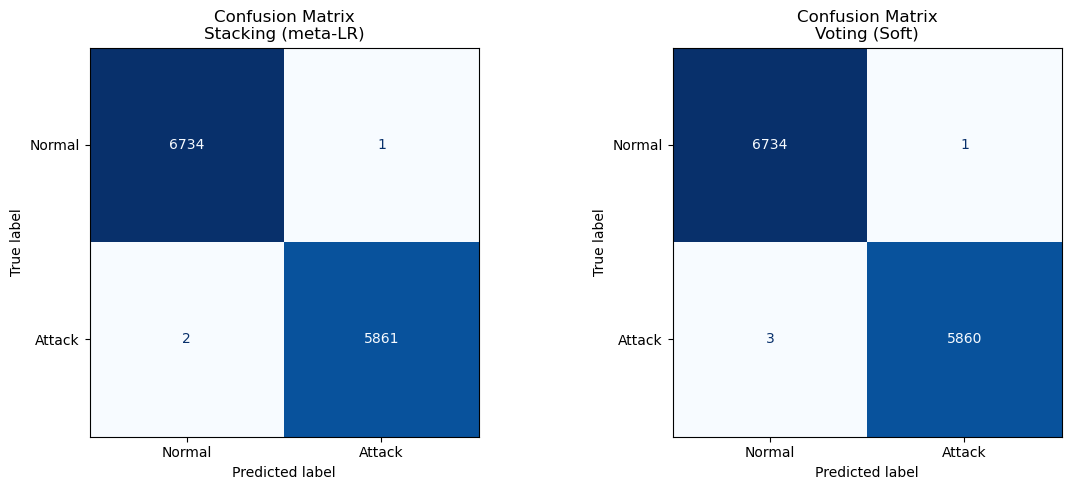

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, (y_pred, _)) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Attack'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix\n{name}', fontsize=12)

plt.tight_layout()
plt.show()

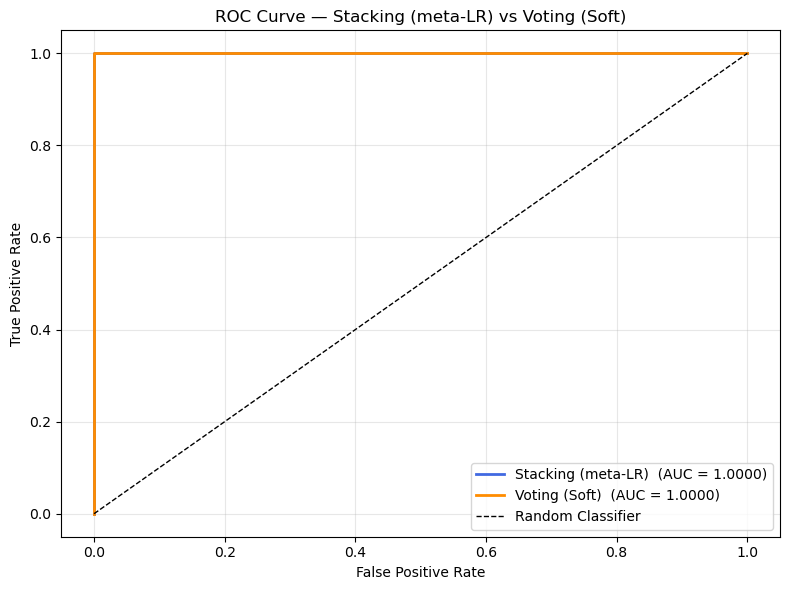

In [26]:
plt.figure(figsize=(8, 6))

colors = ['royalblue', 'darkorange']
for (name, (_, y_prob)), color in zip(models.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, color=color,
             label=f'{name}  (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Stacking (meta-LR) vs Voting (Soft)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


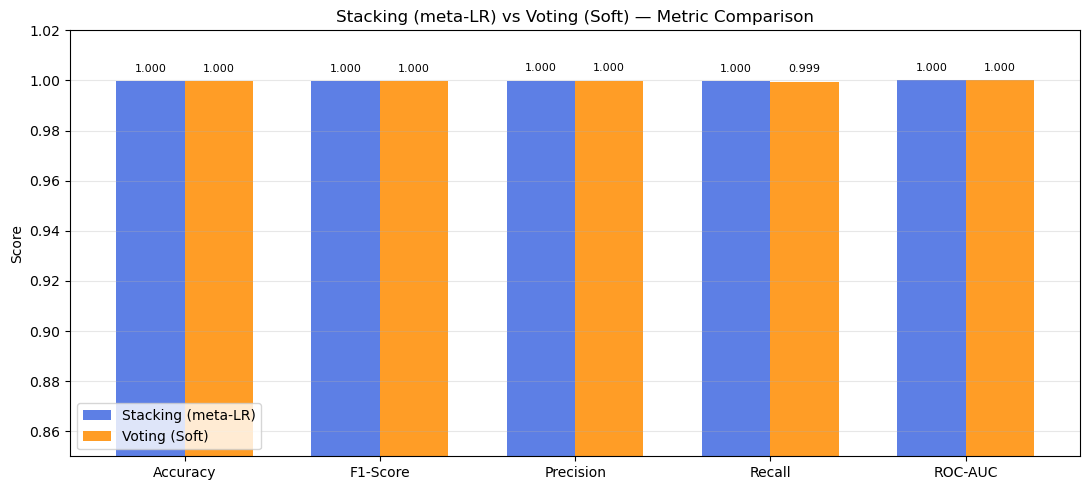

In [27]:
metric_names = ['Accuracy', 'F1-Score', 'Precision', 'Recall', 'ROC-AUC']

results = {}
for name, (y_pred, y_prob) in models.items():
    results[name] = [
        accuracy_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        roc_auc_score(y_test, y_prob),
    ]

x = np.arange(len(metric_names))
width = 0.35
colors = ['royalblue', 'darkorange']

fig, ax = plt.subplots(figsize=(11, 5))
for i, (name, vals) in enumerate(results.items()):
    bars = ax.bar(x + i * width, vals, width,
                  label=name, color=colors[i], alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.003,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width / 2)
ax.set_xticklabels(metric_names)
ax.set_ylim(0.85, 1.02)
ax.set_ylabel('Score')
ax.set_title('Stacking (meta-LR) vs Voting (Soft) — Metric Comparison')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

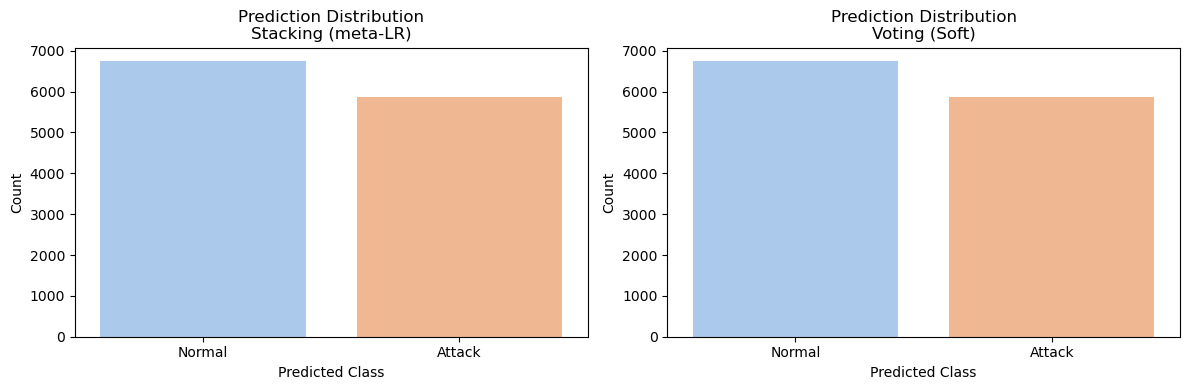

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, (y_pred, _)) in zip(axes, models.items()):
    pred_labels = ['Normal' if p == 0 else 'Attack' for p in y_pred]
    sns.countplot(x=pred_labels, palette='pastel',
                  order=['Normal', 'Attack'], ax=ax)
    ax.set_title(f'Prediction Distribution\n{name}')
    ax.set_xlabel('Predicted Class')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

In [30]:
# ── Individual Base Models Evaluation ────────────────────────────────────────

# Extract fitted base models from stacking and predict
base_model_objects = {
    'XGBoost'         : stacking_model.named_estimators_['xgb'],
    'Random Forest'   : stacking_model.named_estimators_['rf'],
    'Logistic Reg.'   : stacking_model.named_estimators_['lr'],
}

all_results = {}

# ── Score each base model ─────────────────────────────────────────────────────
for name, model in base_model_objects.items():
    y_pred = model.predict(X_test_enc)
    y_prob = model.predict_proba(X_test_enc)[:, 1]
    all_results[name] = {
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall'   : recall_score(y_test, y_pred),
        'F1-Score' : f1_score(y_test, y_pred),
        'AUC-ROC'  : roc_auc_score(y_test, y_prob),
    }

# ── Score ensemble models ─────────────────────────────────────────────────────
for name, (y_pred, y_prob) in models.items():
    all_results[name] = {
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall'   : recall_score(y_test, y_pred),
        'F1-Score' : f1_score(y_test, y_pred),
        'AUC-ROC'  : roc_auc_score(y_test, y_prob),
    }

# ── Build comparison DataFrame ────────────────────────────────────────────────
import pandas as pd

comparison_df = pd.DataFrame(all_results).T
comparison_df = comparison_df[['Accuracy','Precision','Recall','F1-Score','AUC-ROC']]
comparison_df = comparison_df.sort_values('F1-Score', ascending=False)

# ── Print table ───────────────────────────────────────────────────────────────
print("\n  All Models — Performance Comparison")
print("  " + "-" * 68)
print(f"  {'Model':<22} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1-Score':>9} {'AUC-ROC':>8}")
print("  " + "-" * 68)
for model_name, row in comparison_df.iterrows():
    print(f"  {model_name:<22} {row['Accuracy']:>9.4f} {row['Precision']:>10.4f} "
          f"{row['Recall']:>8.4f} {row['F1-Score']:>9.4f} {row['AUC-ROC']:>8.4f}")
print("  " + "-" * 68)

# ── Styled DataFrame display (for Jupyter) ───────────────────────────────────
def highlight_best(s):
    is_best = s == s.max()
    return ['background-color: #d4edda' if v else '' for v in is_best]

comparison_df.style \
    .apply(highlight_best, axis=0) \
    .format("{:.4f}") \
    .set_caption("All Models — Performance Comparison (green = best per metric)") \
    .set_table_styles([{
        'selector': 'caption',
        'props': [('font-size', '14px'), ('font-weight', 'bold'), ('padding', '10px')]
    }])


  All Models — Performance Comparison
  --------------------------------------------------------------------
  Model                   Accuracy  Precision   Recall  F1-Score  AUC-ROC
  --------------------------------------------------------------------
  Random Forest             0.9999     1.0000   0.9998    0.9999   1.0000
  XGBoost                   0.9998     0.9998   0.9997    0.9997   1.0000
  Stacking (meta-LR)        0.9998     0.9998   0.9997    0.9997   1.0000
  Voting (Soft)             0.9997     0.9998   0.9995    0.9997   1.0000
  Logistic Reg.             0.9990     0.9991   0.9986    0.9989   0.9986
  --------------------------------------------------------------------


,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Random Forest,0.9999,1.0000,0.9998,0.9999,1.0000
XGBoost,0.9998,0.9998,0.9997,0.9997,1.0000
Stacking (meta-LR),0.9998,0.9998,0.9997,0.9997,1.0000
Voting (Soft),0.9997,0.9998,0.9995,0.9997,1.0000
Logistic Reg.,0.9990,0.9991,0.9986,0.9989,0.9986
